### [K線捕手](https://www.facebook.com/kevinyang20180801/)  
  
年假第一天，讓大家提早感受過年的感覺~  
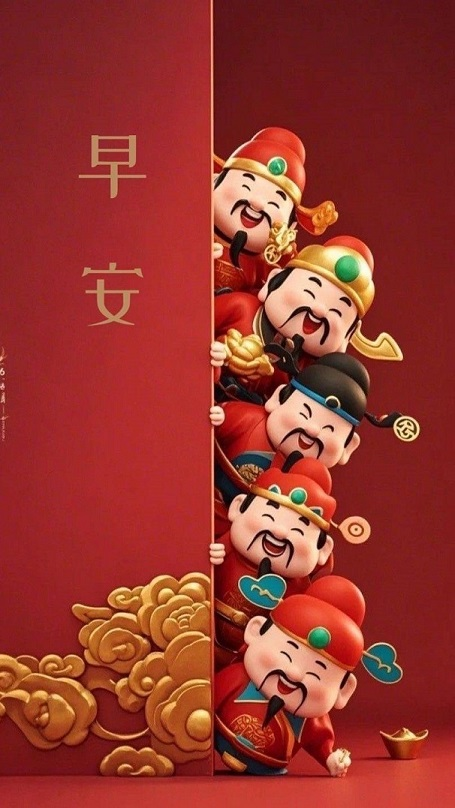  

### 本日進度  
* 「[K線追擊週報](https://smarttest.businessweekly.com.tw/e-subscription/channel?c=GROUP00014146)」訂閱與否於農曆新年假期後決定。  
* **程式開發**：使用轉折點與自動化趨勢線來判斷趨勢 — 延續[1月22日](https://github.com/yilintung/StockInvestmentNotebook/blob/main/250122%E7%AD%86%E8%A8%98.ipynb)工作  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import myutils

In [2]:
# 道氏理論：使用轉折點判斷趨勢
def dow_theory(high_low_points) :
    high_point = None
    low_point = None
    check_results = []
    for idx in range(0,len(high_low_points)) :
        point = high_low_points.iloc[idx]
        if point['Type'] == 'HI' :
            if high_point is not None :
                x = [high_point.name,point.name]
                y = [high_point['Price'],point['Price']]
                slope,intercept = np.polyfit(x,y,1)
                if slope > 0 :
                    check_results.append(1)
                elif slope < 0 :
                    check_results.append(-1)
                else :
                    check_results.append(0)
            high_point = point
        elif point['Type'] == 'LO' :
            if low_point is not None :
                x = [low_point.name,point.name]
                y = [low_point['Price'],point['Price']]
                slope,intercept = np.polyfit(x,y,1)
                if slope > 0 :
                    check_results.append(1)
                elif slope < 0 :
                    check_results.append(-1)
                else :
                    check_results.append(0)
            low_point = point
    identical = (len(set(check_results)) == 1)
    if identical is True:
        if check_results[0] == 1 :
            return('多頭')
        elif check_results[0] == -1 :
            return('空頭')
    return('盤整') 

# 正規化函式
def normalization(data) :
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range

# 轉換正規化斜率成角度
def convert_normalized_slope_to_angle(lines) :
    # 趨勢線價格正規化
    line_prices_list = []
    line_prices_list.append(lines[0][0][1])
    line_prices_list.append(lines[0][1][1])
    line_prices_list.append(lines[1][0][1])
    line_prices_list.append(lines[1][1][1])
    line_prices      = np.array(line_prices_list)
    line_prices_norm = normalization(line_prices)
    # 求斜率並轉換成角度
    line1_x      = [0.0, 1.0]
    line1_y      = [line_prices_norm[0],line_prices_norm[1]]
    line2_x      = [0.0, 1.0]
    line2_y      = [line_prices_norm[2],line_prices_norm[3]]
    line1_angle  = np.rad2deg(np.arctan2(line1_y[1] - line1_y[0] , line1_x[1] - line1_x[0]))
    line2_angle  = np.rad2deg(np.arctan2(line2_y[1] - line2_y[0] , line2_x[1] - line2_x[0]))
    return line1_angle,line2_angle

# 移動平均線趨勢判定程序(短期與中期)
# 來源：https://ithelp.ithome.com.tw/articles/10315635
def moving_average_trend(sma):
    now_sma  = sma.iloc[-1].to_dict()
    prev_sma = sma.iloc[-2].to_dict()
    # 確認移動平均線方向：↑ : 'u' , ↓ : 'd' , ＝ : '='
    sma5_dir = 'u' if now_sma['SMA5'] > prev_sma['SMA5'] else 'd' if now_sma['SMA5'] < prev_sma['SMA5'] else '='
    sma10_dir = 'u' if now_sma['SMA10'] > prev_sma['SMA10'] else 'd' if now_sma['SMA10'] < prev_sma['SMA10'] else '='
    sma20_dir = 'u' if now_sma['SMA20'] > prev_sma['SMA20'] else 'd' if now_sma['SMA20'] < prev_sma['SMA20'] else '='
    sma60_dir = 'u' if now_sma['SMA60'] > prev_sma['SMA60'] else 'd' if now_sma['SMA60'] < prev_sma['SMA60'] else '='
    sma120_dir = 'u' if now_sma['SMA120'] > prev_sma['SMA120'] else 'd' if now_sma['SMA120'] < prev_sma['SMA120'] else '='
    sma240_dir = 'u' if now_sma['SMA240'] > prev_sma['SMA240'] else 'd' if now_sma['SMA240'] < prev_sma['SMA240'] else '='
    # 短期趨勢
    if sma5_dir == sma10_dir :
        if sma5_dir == 'u' :
            print('短期趨勢：多頭')
        elif sma5_dir == 'd' :
            print('短期趨勢：空頭')
    else :
        print('短期趨勢：盤整')
    # 中期趨勢
    if sma20_dir == sma60_dir :
        if sma20_dir == 'u' :
            print('中期趨勢：多頭')
        elif sma20_dir == 'd' :
            print('中期趨勢：空頭')
    else :
        print('中期趨勢：盤整')

In [3]:
##### 使用2024年8月15日到今日(2025年1月22日)收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_250122.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

# 移動平均線判定趨勢(短期與中期)
moving_average_trend(df_sma)

短期趨勢：多頭
中期趨勢：多頭


In [4]:
# 趨勢判別程序(開發中，程序待檢討)
def test_trend_identification(prices,sma,start_date,end_date,proid = 1,mode = 'open_close') :
    range_prices = prices[start_date:end_date]
    range_sma    = sma[start_date:end_date]
    # 使用轉折點判斷趨勢
    turning_points = myutils.test_DetectTurningPoints(range_prices,range_sma,mode=mode,period=proid)
    dow_ret = None
    if turning_points is None or turning_points.shape[0] < 4 :
        # 使用自動化趨勢線判斷趨勢
        params,lines = myutils.test_TrendlineAutomation(prices, range_start_date = start_date, range_end_date = end_date, mode=mode)
        # 斜率正規化後轉角度
        line1_angle,line2_angle = convert_normalized_slope_to_angle(lines)
        print()
        if line1_angle > 5.0 and line2_angle > 5.0 :
            print('☆ 由自動化趨勢線判斷趨勢為 多頭')
        elif line1_angle < -5.0 and line2_angle < -5.0 :
            print('☆ 由自動化趨勢線判斷趨勢為 空頭')
        else :
            print('☆ 由自動化趨勢線判斷趨勢為 盤整')
        print()
    else :    
        dow_ret = dow_theory(turning_points)
    if dow_ret is not None :    
        print();print('★ 由轉折點判斷趨勢為 {}'.format(dow_ret));print()

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 1 ， 最小化過濾器的距離參數 ＝ 1 
轉折點總筆數 ＝ 0


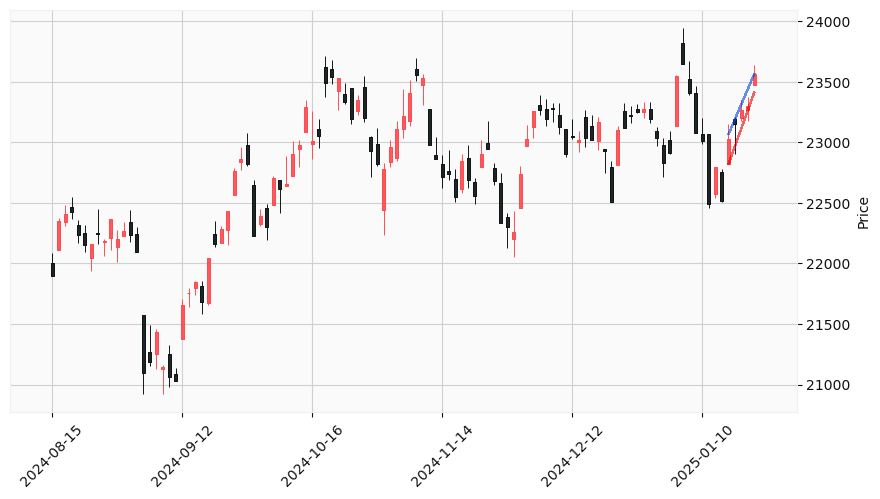


☆ 由自動化趨勢線判斷趨勢為 多頭



In [5]:
# 5日
start_date   = df_k_line.iloc[-5].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,1)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 1 ， 最小化過濾器的距離參數 ＝ 1 
轉折點總筆數 ＝ 2


,Date,Price,Type
DateIndex,,,
2,2025-01-13,23070.32,HI
4,2025-01-15,22514.57,LO


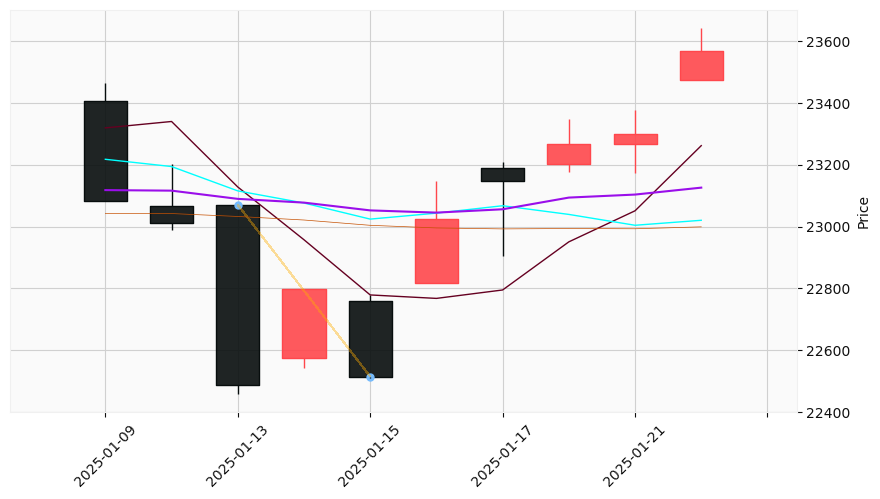

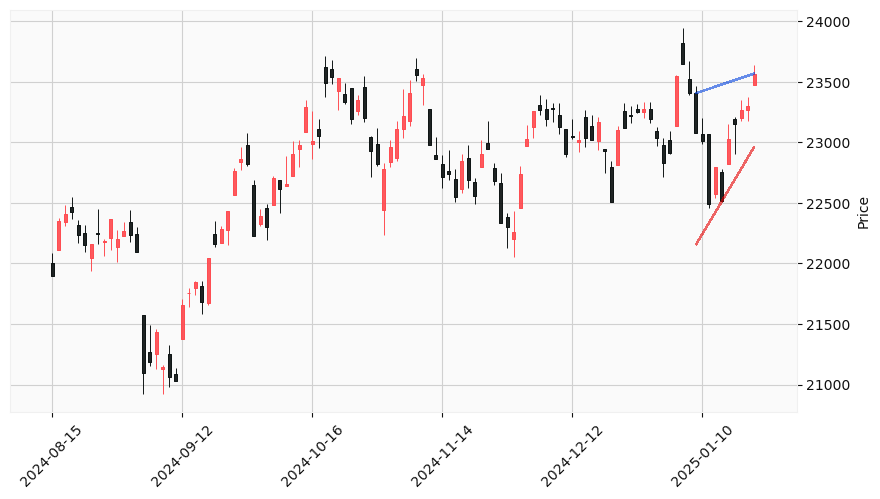


☆ 由自動化趨勢線判斷趨勢為 多頭



In [6]:
# 10日
start_date   = df_k_line.iloc[-10].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,1)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 5 ， 最小化過濾器的距離參數 ＝ 2 
轉折點總筆數 ＝ 4


,Date,Price,Type
DateIndex,,,
1,2024-12-26,23276.08,HI
5,2025-01-02,22832.06,LO
8,2025-01-07,23824.72,HI
12,2025-01-13,22488.33,LO


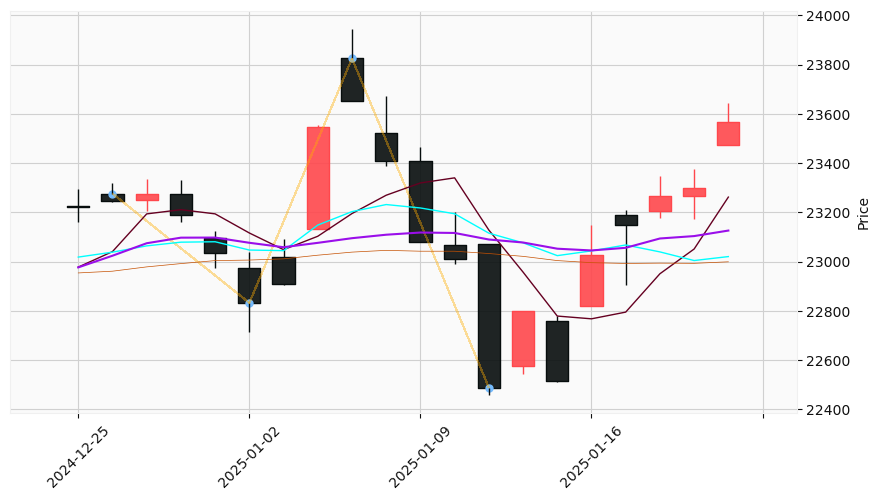


★ 由轉折點判斷趨勢為 盤整



In [7]:
# 20日
start_date   = df_k_line.iloc[-20].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,20//4)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 15 ， 最小化過濾器的距離參數 ＝ 7 
轉折點總筆數 ＝ 7


,Date,Price,Type
DateIndex,,,
2,2024-11-01,22438.93,LO
7,2024-11-08,23608.11,HI
22,2024-11-29,22202.28,LO
26,2024-12-05,23308.29,HI
37,2024-12-20,22510.25,LO
48,2025-01-07,23824.72,HI
52,2025-01-13,22488.33,LO


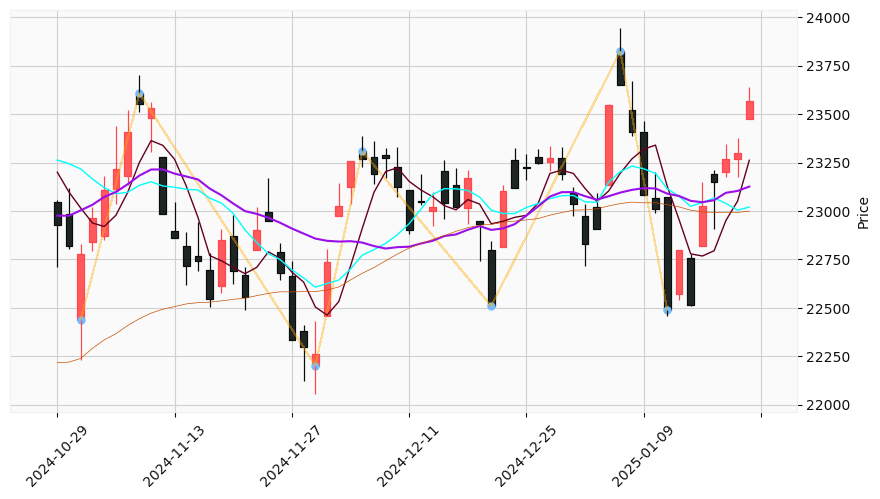


★ 由轉折點判斷趨勢為 盤整



In [8]:
# 60日
start_date   = df_k_line.iloc[-60].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,60//4)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 10


,Date,Price,Type
DateIndex,,,
3,2024-08-20,22464.07,HI
19,2024-09-11,21031.00,LO
42,2024-10-18,23620.57,HI
51,2024-11-01,22438.93,LO
56,2024-11-08,23608.11,HI
71,2024-11-29,22202.28,LO
75,2024-12-05,23308.29,HI
86,2024-12-20,22510.25,LO
97,2025-01-07,23824.72,HI


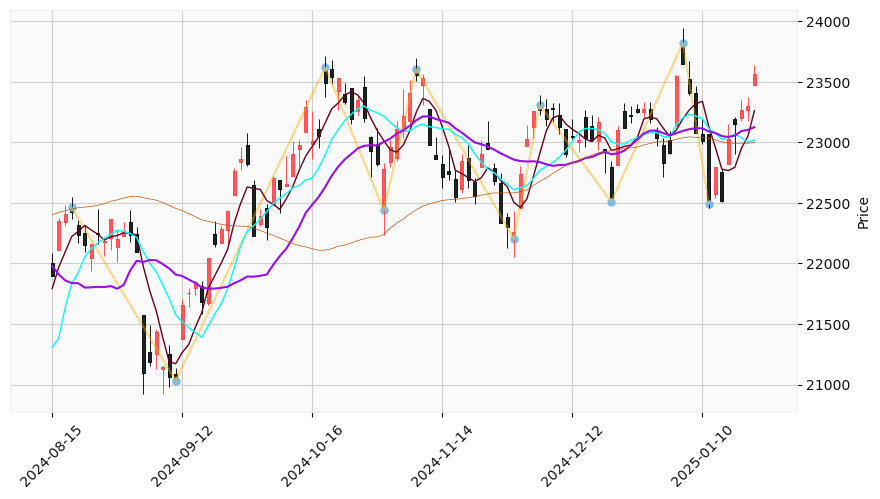


★ 由轉折點判斷趨勢為 盤整



In [9]:
# 全區間
start_date   = df_k_line.iloc[0].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,20)

In [10]:
##### 使用2024年7月22日到今日(2025年1月22日)收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_OTC_250122.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

# 移動平均線判定趨勢(短期與中期)
moving_average_trend(df_sma)

短期趨勢：盤整
中期趨勢：空頭


ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 1 ， 最小化過濾器的距離參數 ＝ 1 
轉折點總筆數 ＝ 1


,Date,Price,Type
DateIndex,,,
2,2025-01-20,248.04,LO


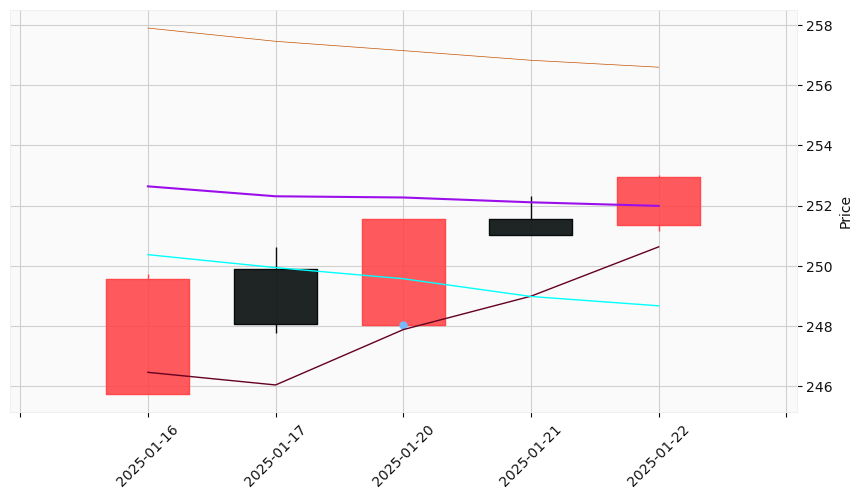

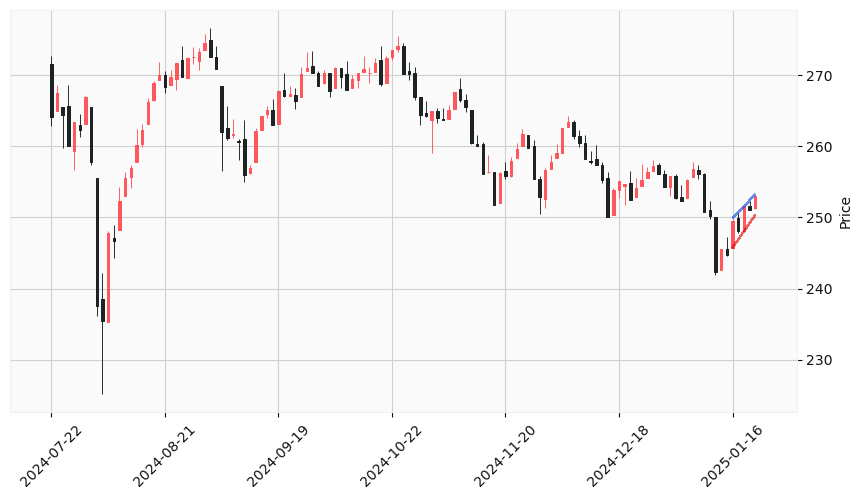


☆ 由自動化趨勢線判斷趨勢為 多頭



In [11]:
# 5日
start_date   = df_k_line.iloc[-5].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,1)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 1 ， 最小化過濾器的距離參數 ＝ 1 
轉折點總筆數 ＝ 1


,Date,Price,Type
DateIndex,,,
2,2025-01-13,242.35,LO


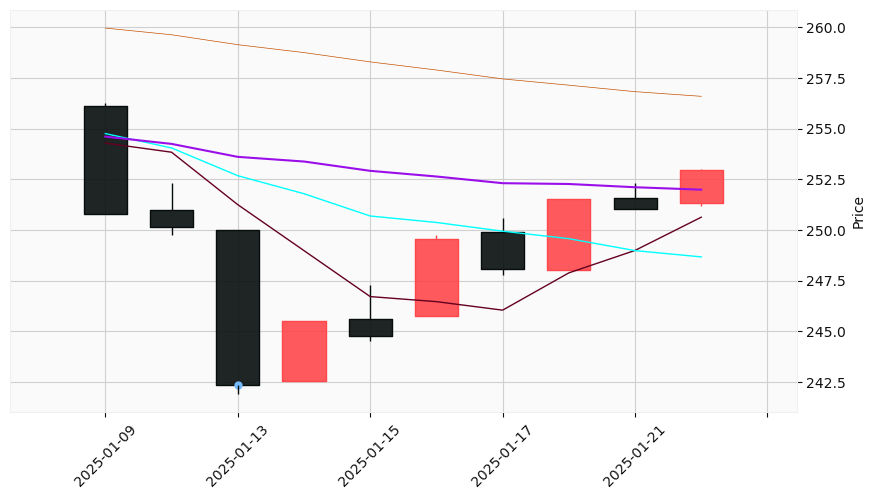

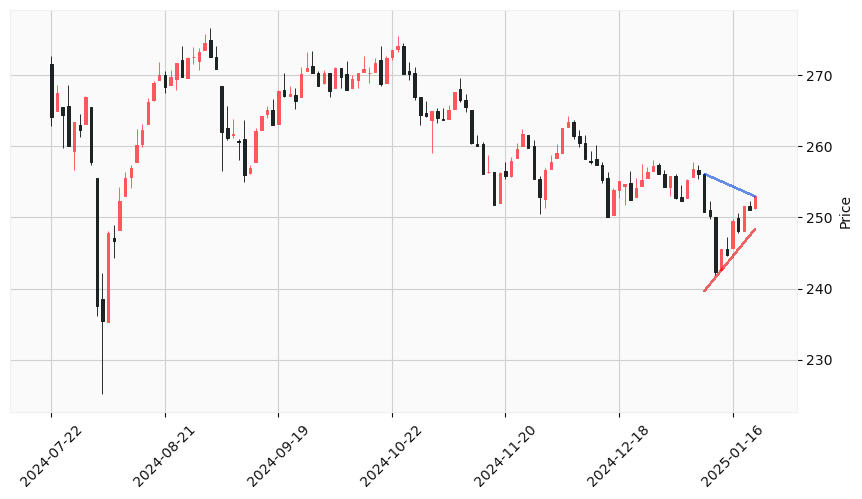


☆ 由自動化趨勢線判斷趨勢為 盤整



In [12]:
# 10日
start_date   = df_k_line.iloc[-10].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,1)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 5 ， 最小化過濾器的距離參數 ＝ 2 
轉折點總筆數 ＝ 4


,Date,Price,Type
DateIndex,,,
2,2024-12-27,257.31,HI
6,2025-01-03,252.35,LO
8,2025-01-07,256.88,HI
12,2025-01-13,242.35,LO


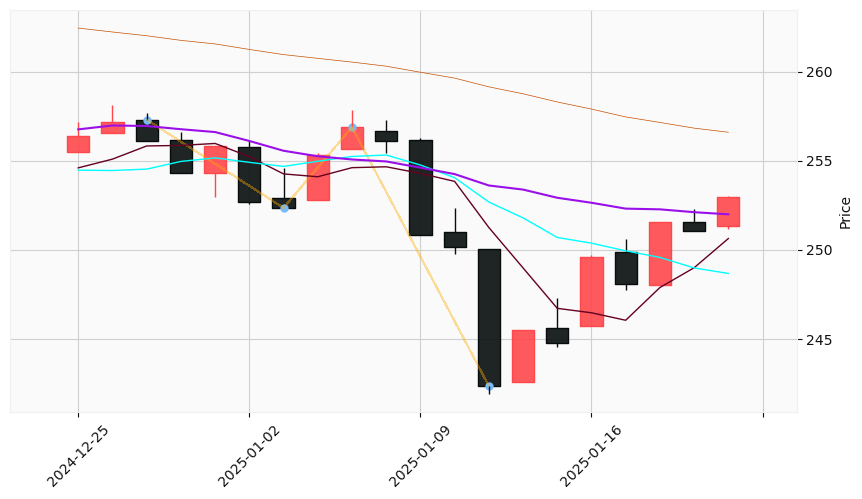


★ 由轉折點判斷趨勢為 空頭



In [13]:
# 20日
start_date   = df_k_line.iloc[-20].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,20//4)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 15 ， 最小化過濾器的距離參數 ＝ 7 
轉折點總筆數 ＝ 6


,Date,Price,Type
DateIndex,,,
7,2024-11-08,268.08,HI
13,2024-11-18,251.78,LO
26,2024-12-05,263.39,HI
33,2024-12-16,250.10,LO
42,2024-12-27,257.31,HI
52,2025-01-13,242.35,LO


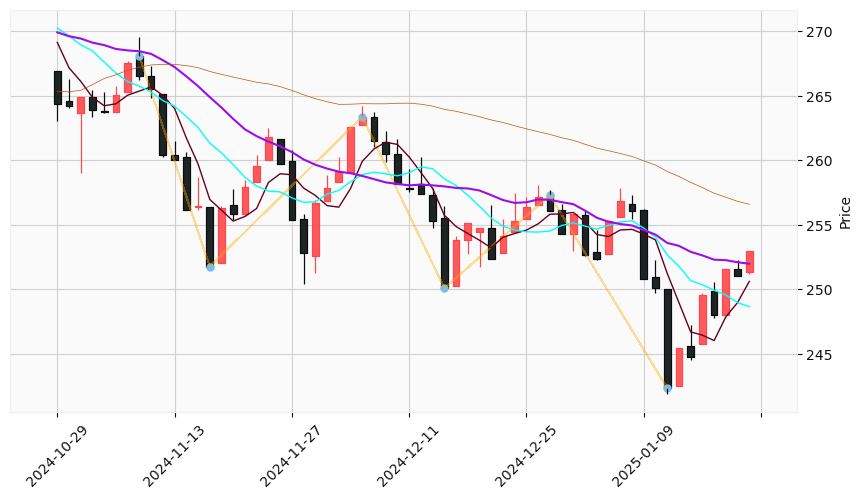


★ 由轉折點判斷趨勢為 空頭



In [14]:
# 60日
start_date   = df_k_line.iloc[-60].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,60//4)

ＤＥＢＵＧ ： 峰谷最小寬度 ＝ 21 ， 最小化過濾器的距離參數 ＝ 10 
轉折點總筆數 ＝ 7


,Date,Price,Type
DateIndex,,,
10,2024-08-07,235.31,LO
28,2024-09-02,274.91,HI
34,2024-09-10,256.00,LO
62,2024-10-24,274.16,HI
78,2024-11-18,251.78,LO
91,2024-12-05,263.39,HI
117,2025-01-13,242.35,LO


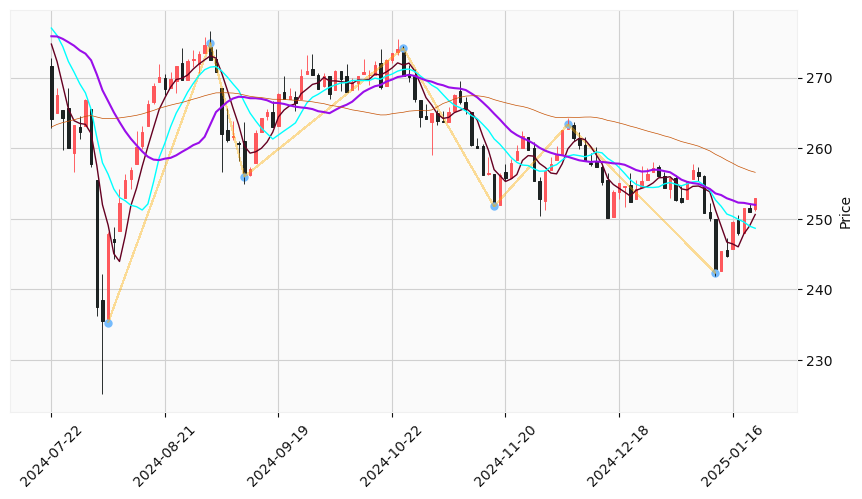


★ 由轉折點判斷趨勢為 盤整



In [15]:
# 全區間
start_date   = df_k_line.iloc[0].name.strftime("%Y-%m-%d")
end_date     = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
test_trend_identification(df_k_line,df_sma,start_date,end_date,20)